In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
names = open('names.txt', 'r').read().splitlines()
names[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
len(names)

32033

In [ ]:
chars = sorted(list(set(''.join(names))))
chars[:5]

['a', 'b', 'c', 'd', 'e']

In [ ]:
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [ ]:
type(stoi.items())

dict_items

In [ ]:
xs, ys = [], []

block_size = 3

for name in names[:5]:
  print(name)
  context = [0]*block_size
  for ch in name + '.':
    ix = stoi[ch]
    print(''.join(itos[i] for i in context) + '---->' + ch)
    xs.append(context)
    ys.append(ix)
    context = context[1:] + [ix]
  print('-------------------')

emma
...---->e
..e---->m
.em---->m
emm---->a
mma---->.
-------------------
olivia
...---->o
..o---->l
.ol---->i
oli---->v
liv---->i
ivi---->a
via---->.
-------------------
ava
...---->a
..a---->v
.av---->a
ava---->.
-------------------
isabella
...---->i
..i---->s
.is---->a
isa---->b
sab---->e
abe---->l
bel---->l
ell---->a
lla---->.
-------------------
sophia
...---->s
..s---->o
.so---->p
sop---->h
oph---->i
phi---->a
hia---->.
-------------------


In [ ]:
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [ ]:
xs.shape

torch.Size([32, 3])

In [ ]:
ys.shape

torch.Size([32])

In [ ]:
C = torch.randn((27, 2))

In [ ]:
C[5]

tensor([-1.1368,  0.5553])

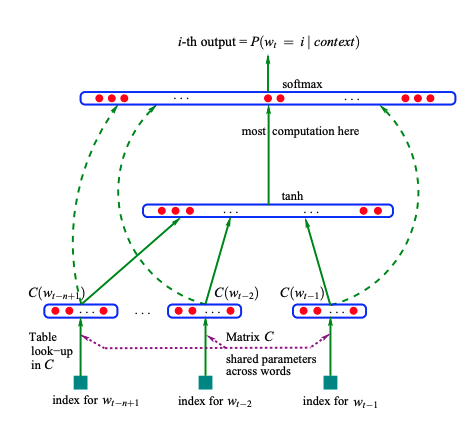

Equivalent interpretation to indexing is considering the C embedding layer as the hidden layer

In [ ]:
F.one_hot(torch.tensor(5), num_classes= 27).float() @ C # cast to float before matrix multiply

tensor([-1.1368,  0.5553])

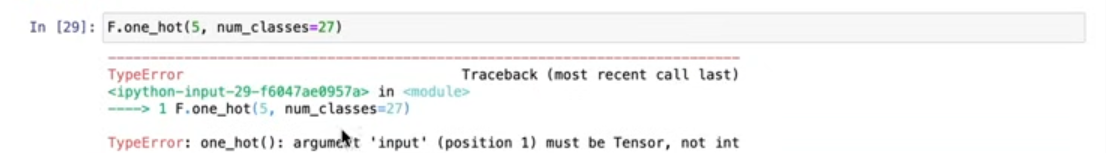

In [ ]:
embed = C[xs]

In [ ]:
embed.shape

torch.Size([32, 3, 2])

In [ ]:
import numpy as np
assert np.allclose(C[xs[12, 1]], embed[12, 1])

In [ ]:
C[xs[12, 1]]

tensor([-0.8037,  0.2709])

In [ ]:
embed[12, 1]

tensor([-0.8037,  0.2709])

We'd like to be able to do something like embed @ W + b to go from the embedding layer to the hidden layer. <br>

But this is not possible with the dimensions being unflattened at [32, (3,2)]
We would want something like [32, 6]

Many ways of accomplishing this


In [ ]:
torch.cat([embed[:, 0, :], embed[:, 1, :], embed[:, 2, :]], dim = 1).shape

torch.Size([32, 6])

But not re-usable for varying sizes of block size

In [ ]:
len(torch.unbind(embed, 1))

3

In [ ]:
torch.unbind(embed, 1)[0].shape

torch.Size([32, 2])

In [ ]:
torch.cat(torch.unbind(embed, 1), dim=1).shape # dim 1 of shape [32, 2]

torch.Size([32, 6])

In [ ]:
assert np.allclose(torch.cat([embed[:, 0, :], embed[:, 1, :], embed[:, 2, :]], dim = 1), torch.cat(torch.unbind(embed, 1), dim=1))

But unbind then cat --> creates an entirely new tensor. So it is inefficient both in computation and storage. <br>

A much better option is to use .view(), same storage multiple views
http://blog.ezyang.com/2019/05/pytorch-internals/


In [ ]:
embed.view(embed.shape[0], -1) # -1 makes PyTorch infer the remaining dimension automatically based on the other specified dimensions

tensor([[-0.8037,  0.2709, -0.8037,  0.2709, -0.8037,  0.2709],
        [-0.8037,  0.2709, -0.8037,  0.2709, -1.1368,  0.5553],
        [-0.8037,  0.2709, -1.1368,  0.5553,  0.4998, -1.1550],
        [-1.1368,  0.5553,  0.4998, -1.1550,  0.4998, -1.1550],
        [ 0.4998, -1.1550,  0.4998, -1.1550, -0.2519,  1.1021],
        [-0.8037,  0.2709, -0.8037,  0.2709, -0.8037,  0.2709],
        [-0.8037,  0.2709, -0.8037,  0.2709, -0.6140,  1.7462],
        [-0.8037,  0.2709, -0.6140,  1.7462,  0.3108, -0.7262],
        [-0.6140,  1.7462,  0.3108, -0.7262, -1.2603, -0.4843],
        [ 0.3108, -0.7262, -1.2603, -0.4843,  2.2528,  1.5988],
        [-1.2603, -0.4843,  2.2528,  1.5988, -1.2603, -0.4843],
        [ 2.2528,  1.5988, -1.2603, -0.4843, -0.2519,  1.1021],
        [-0.8037,  0.2709, -0.8037,  0.2709, -0.8037,  0.2709],
        [-0.8037,  0.2709, -0.8037,  0.2709, -0.2519,  1.1021],
        [-0.8037,  0.2709, -0.2519,  1.1021,  2.2528,  1.5988],
        [-0.2519,  1.1021,  2.2528,  1.5

In [ ]:
embed_size = 2
W1 = torch.randn((block_size*embed_size, 100))
b1 = torch.randn(100) # automatic broadcasting 100 over 6*100 by broadcast rule 1*100 over 6*100
hidden = torch.tanh(embed.view(embed.shape[0], -1) @ W1 + b1)

In [ ]:
hidden.shape

torch.Size([32, 100])

In [ ]:
W2 = torch.randn((100, 27)) # want 27 logits each corresponding to log-counts of output character
b2 = torch.randn(27)
logits = hidden @ W2 + b2
counts = logits.exp()   #exponentiating log-counts gives counts
probs = counts/counts.sum(1, keepdims=True) #softmax of counts gives probabilities

In [ ]:
#probs corresponding to expected output labels

actual_output_probs = probs[torch.arange(xs.shape[0]), ys]

In [ ]:
log_likeli = actual_output_probs.log()
mean_log_likeli = log_likeli.mean()
nll = - mean_log_likeli

In [ ]:
nll

tensor(17.7456)

## Putting it all together

In [ ]:
# Creating dataset
xs, ys = [], []

block_size = 3
embed_size = 2
vocab_size = 27
hidden_size = 100
output_size = vocab_size

for name in names[:5]:
  context = [0]*block_size
  for ch in name + '.':
    ix = stoi[ch]
    xs.append(context)
    ys.append(ix)
    context = context[1:] + [ix]

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [ ]:
# initialize parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size), generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, output_size), generator=g)
b2 = torch.randn(output_size, generator=g)

parameters = [C, W1, b1, W2, b2]

In [ ]:
parameters[0].nelement()

54

In [ ]:
sum([p.nelement() for p in parameters])

3481

In [ ]:
# parameters[0].grad

In [ ]:
# forward pass

embed = C[xs]
hidden = torch.tanh(embed.view(xs.shape[0], -1) @ W1 + b1)
logits = hidden @ W2 + b2

counts = logits.exp()
probs = counts/counts.sum(1, keepdims=True)
log_likeli = probs[torch.arange(xs.shape[0]), ys].log().mean()
nll = -log_likeli


In [ ]:
nll

tensor(17.7697)

## Optimizing the loss calculation using PyTorch cross entropy

In [ ]:
nll = F.cross_entropy(logits, ys)
nll

tensor(17.7697)

In [ ]:
# nn implementation also gives the same loss calculation
criterion = nn.CrossEntropyLoss()

# Calculate loss
loss = criterion(logits, ys)
loss

tensor(17.7697)

In [ ]:
pred = F.log_softmax(logits, dim=-1)
loss = F.nll_loss(pred, ys)
loss

tensor(17.7697)

In [ ]:
## equivalent to log_softmax, so log_softmax is softmax then log
count = logits.exp()
count = count / count.sum(1, keepdim=True)
count[0].log()

tensor([-19.7983, -22.3187,  -8.4468, -23.1641, -26.7930, -31.8166, -41.5179,
        -11.6898, -19.2123,  -1.9515,  -0.1536, -25.9804, -22.4427, -22.3947,
         -9.2651, -22.9467, -19.4475, -16.1028, -15.0937, -19.7355, -24.5233,
        -19.5541, -26.0586, -24.6219, -11.5705, -18.9863, -12.5772])

In [ ]:
pred[0], ys[0]

(tensor([-19.7983, -22.3187,  -8.4468, -23.1641, -26.7930, -31.8166, -41.5179,
         -11.6898, -19.2123,  -1.9515,  -0.1536, -25.9804, -22.4427, -22.3947,
          -9.2651, -22.9467, -19.4475, -16.1028, -15.0937, -19.7355, -24.5233,
         -19.5541, -26.0586, -24.6219, -11.5705, -18.9863, -12.5772]),
 tensor(5))

# DETOUR: Major benefits of using cross_entropy over custom implementation



1.   Creates less new objects, therefore using less memory
2.   Benefits of fused kernel operations (eg. tanh implementation from micrograd - either fused or broken in to individual ops - the fused op has a much simpler backward grad calculation)
3.   Forward pass and backward pass are therefore more efficient
4.   Numerically well behaved when it comes to exponentiating big numbers(refer example below)


In [ ]:
# general numbers have no issues
temp = torch.tensor([1, 2, 3, 4, 5])
count_temp = temp.exp()
prob_temp = count_temp/count_temp.sum()
prob_temp

tensor([0.0117, 0.0317, 0.0861, 0.2341, 0.6364])

In [ ]:
# highly negative numbers also have no issues
temp = torch.tensor([-100, 2, 3, 4, 5])
count_temp = temp.exp()
prob_temp = count_temp/count_temp.sum()
prob_temp

tensor([0.0000, 0.0321, 0.0871, 0.2369, 0.6439])

In [ ]:
# highly positive numbers however, due to the nature of exp()
temp = torch.tensor([-100, 2, 3, 4, 100])
count_temp = temp.exp()
prob_temp = count_temp/count_temp.sum()
prob_temp

tensor([0., 0., 0., 0., nan])

In [ ]:
# internal PyTorch correction/handling of this issue by shifting values back by the max
# this works out because
temp = torch.tensor([-100, 2, 3, 4, 100])
temp -= temp.max()
count_temp = temp.exp()
prob_temp = count_temp/count_temp.sum()
prob_temp

tensor([0.0000e+00, 2.7465e-43, 7.4689e-43, 2.0305e-42, 1.0000e+00])

Understanding how subtracted max makes no difference

In [ ]:
# ORIGINAL VERSION
temp = torch.tensor([1, 2, 3, 4, 5])
count_temp = temp.exp()
prob_temp = count_temp/count_temp.sum()
prob_temp

tensor([0.0117, 0.0317, 0.0861, 0.2341, 0.6364])

In [ ]:
# SUBTRACTED MAX VERSION
temp = torch.tensor([-4, -3, -2, -1, 0])
# ----> e^(x-t) = e^x/e^t would get cancelled out, and gives the same output
# because every term in norm-numerator has e^t in denominator and the sum in the norm-denominator also has e^t in denominator
count_temp = temp.exp()
prob_temp = count_temp/count_temp.sum()
prob_temp

tensor([0.0117, 0.0317, 0.0861, 0.2341, 0.6364])

## Putting it all together AGAIN

In [ ]:
# Creating dataset
xs, ys = [], []

block_size = 3
embed_size = 2
vocab_size = 27
hidden_size = 100
output_size = vocab_size

for name in names[:5]:
  context = [0]*block_size
  for ch in name + '.':
    ix = stoi[ch]
    xs.append(context)
    ys.append(ix)
    context = context[1:] + [ix]

xs = torch.tensor(xs)
ys = torch.tensor(ys)

# initialize parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size), generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, output_size), generator=g)
b2 = torch.randn(output_size, generator=g)

parameters = [C, W1, b1, W2, b2]

In [ ]:
xs.shape, sum(p.nelement() for p in parameters)

(torch.Size([32, 3]), 3481)

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
for _ in range(1000):
  # forward pass

  embed = C[xs]
  hidden = torch.tanh(embed.view(xs.shape[0], -1) @ W1 + b1)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, ys)

  # backward pass
  for p in parameters: #--> equivalent to zero grad
    p.grad = None

  loss.backward()

  # update weights
  for p in parameters:
    p.data += -0.1 * p.grad

print(loss.item())

0.2561509907245636


## process of overfitting to a single batch of data - not doing considered one of the major sins!!

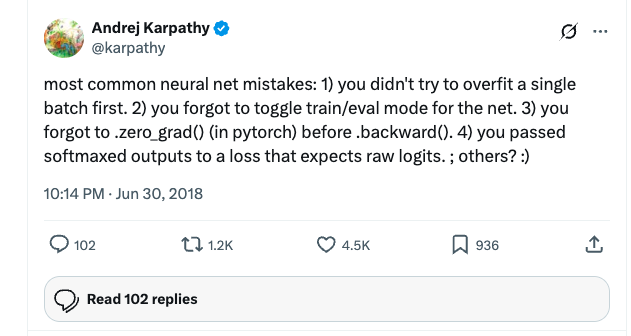

## Only 32 examples and total number of parameters 3481 -->

But we still can't overfit i.e. get 0 loss
That is because there are examples in our dataset that are equally probable!

Notice dataset samples <br>
... -> e <br>
... -> o <br>
... -> i <br>


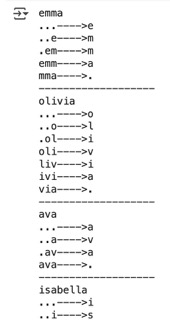

In [ ]:
logits.max(1) ## returns both max values and max indices, argmax only returns indices

torch.return_types.max(
values=tensor([13.3437, 17.7879, 20.5832, 20.6042, 16.7390, 13.3437, 15.9747, 14.1889,
        15.9158, 18.3894, 15.9409, 20.9284, 13.3437, 17.1212, 17.1498, 20.0637,
        13.3437, 16.4564, 15.1328, 17.0537, 18.5905, 15.9655, 10.8739, 10.6874,
        15.5062, 13.3437, 16.2394, 16.9563, 12.7426, 16.2141, 19.0840, 16.0213],
       grad_fn=<MaxBackward0>),
indices=tensor([ 9, 13, 13,  1,  0,  9, 12,  9, 22,  9,  1,  0,  9, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0,  9, 15, 16,  8,  9,  1,  0]))

In [ ]:
ys

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

Resulting indices almost match ys but not exactly because of the "equally probable" samples in the dataset. But the model does overfit to unique examples in the dataset eg. oli --> v

## Another Detour : torch.max vs torch.argmax --> signal to remember CS 4782 Midterm improvement


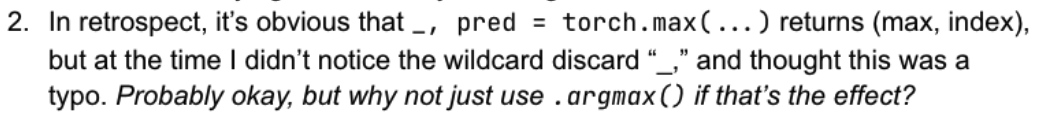

# Training on the entire dataset

In [ ]:
# Creating dataset
xs, ys = [], []

block_size = 3
embed_size = 2
vocab_size = 27
hidden_size = 100
output_size = vocab_size

for name in names:
  context = [0]*block_size
  for ch in name + '.':
    ix = stoi[ch]
    xs.append(context)
    ys.append(ix)
    context = context[1:] + [ix]

xs = torch.tensor(xs)
ys = torch.tensor(ys)

# initialize parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size), generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, output_size), generator=g)
b2 = torch.randn(output_size, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [ ]:
xs.shape

torch.Size([228146, 3])

In [ ]:
for _ in range(10):
  # forward pass

  embed = C[xs]
  hidden = torch.tanh(embed.view(xs.shape[0], -1) @ W1 + b1)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, ys)

  # backward pass
  for p in parameters: #--> equivalent to zero grad
    p.grad = None

  loss.backward()

  # update weights
  for p in parameters:
    p.data += -0.1 * p.grad

print(loss.item())

8.521749496459961




## Moving from GD to Mini-batch GD
Training is now significantly slow, need to fix!

Using batching

```It's always better 'to have a appox gradient direction and take more steps' to reach the minima THAN it is 'to have an accurate gradient direction to want to take lesser steps'"```

In [ ]:
xs.shape

torch.Size([228146, 3])

In [ ]:
for _ in range(10):
  # forward pass

  # randomly sample a minibatch of size 32 from the dataset of size 228146
  # so it is not just minibatch GD but also stochastic!
  ind = torch.randint(0, xs.shape[0], (32, )) # so stupid that it takes a tuple, but I do see the generalizability aspect

  embed = C[xs[ind]]
  hidden = torch.tanh(embed.view(xs[ind].shape[0], -1) @ W1 + b1)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, ys[ind])

  # backward pass
  for p in parameters: #--> equivalent to zero grad
    p.grad = None

  print(loss.item())
  loss.backward()


  # update weights
  for p in parameters:
    p.data += -0.1 * p.grad


4.528701305389404
6.009932041168213
4.317732334136963
4.137841701507568
6.055032253265381
4.737154006958008
3.620748281478882
4.302829265594482
3.287026882171631
4.052079677581787


Very close to the minima but circling about it.

Maybe now a good time to go back to GD instead of mini-batching

In [ ]:
for _ in range(5):
  # forward pass

  # randomly sample a minibatch of size 32 from the dataset of size 228146
  # ind = torch.randint(0, xs.shape[0], (32, )) # so stupid that it takes a tuple, but I do see the generalizability aspect

  embed = C[xs]
  hidden = torch.tanh(embed.view(xs.shape[0], -1) @ W1 + b1)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, ys)

  # backward pass
  for p in parameters: #--> equivalent to zero grad
    p.grad = None

  print(loss.item())
  loss.backward()


  # update weights
  for p in parameters:
    p.data += -0.5 * p.grad

3.9095754623413086
4.0671257972717285
3.6350202560424805
3.705495595932007
3.652064085006714


# Learning Rate Decay - finding optimal lr using an elbow plot

since towards the end the loss was circling about the minima

In [ ]:
lri = torch.linspace(-3, 0, 1000)
lre = 10**lri

In [ ]:
lri_list = []
lre_list = []
loss_lr = []

for i in range(1000):
  # forward pass

  # randomly sample a minibatch of size 32 from the dataset of size 228146
  ind = torch.randint(0, xs.shape[0], (32, )) # so stupid that it takes a tuple, but I do see the generalizability aspect

  embed = C[xs[ind]]
  hidden = torch.tanh(embed.view(xs[ind].shape[0], -1) @ W1 + b1)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, ys[ind])

  # backward pass
  for p in parameters: #--> equivalent to zero grad
    p.grad = None

  # print(loss.item())
  loss.backward()


  # update weights
  lr = lre[i]

  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lri_list.append(lri[i])
  lre_list.append(lre[i])
  loss_lr.append(loss.item())

print(loss.item())

10.642504692077637


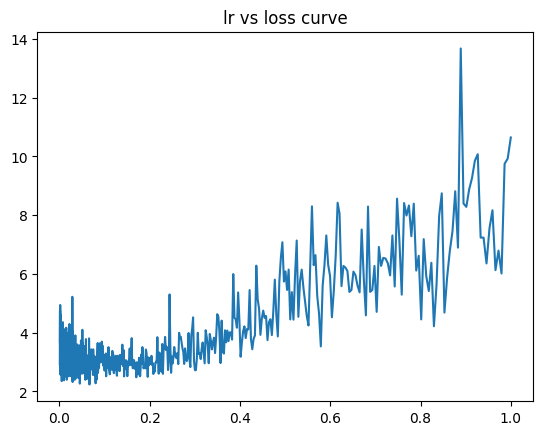

In [ ]:
plt.title("lr vs loss curve") # ideal lr is between 0 and 0.2
plt.plot(lre_list, loss_lr)

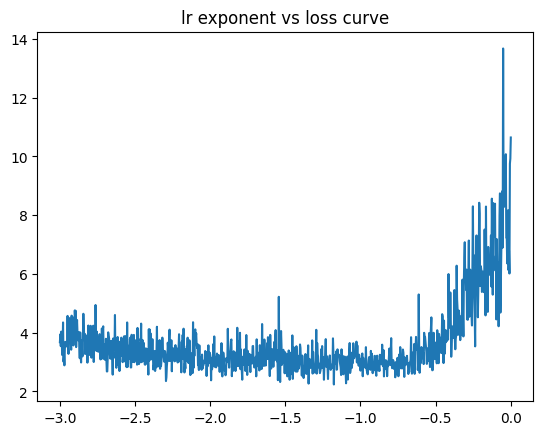

In [ ]:
plt.title("lr exponent vs loss curve") # ideal exponent is between -1 and -0.5
plt.plot(lri_list, loss_lr)

# sticking to original 0.1 and re-train from scratch


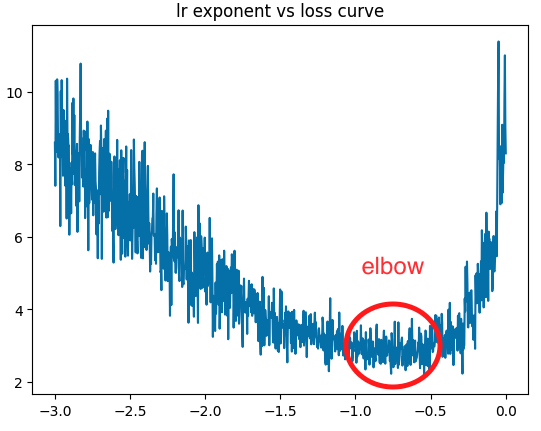

In [ ]:
# Creating dataset
xs, ys = [], []

block_size = 3
embed_size = 2
vocab_size = 27
hidden_size = 100
output_size = vocab_size

for name in names:
  context = [0]*block_size
  for ch in name + '.':
    ix = stoi[ch]
    xs.append(context)
    ys.append(ix)
    context = context[1:] + [ix]

xs = torch.tensor(xs)
ys = torch.tensor(ys)

# initialize parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size), generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, output_size), generator=g)
b2 = torch.randn(output_size, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [ ]:
for i in range(10000):
  # forward pass

  # randomly sample a minibatch of size 32 from the dataset of size 228146
  ind = torch.randint(0, xs.shape[0], (32, )) # so stupid that it takes a tuple, but I do see the generalizability aspect

  embed = C[xs[ind]]
  hidden = torch.tanh(embed.view(xs[ind].shape[0], -1) @ W1 + b1)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, ys[ind])

  # backward pass
  for p in parameters: #--> equivalent to zero grad
    p.grad = None

  loss.backward()


  # update weights
  lr = 10**-1
  lr = 0.01

  for p in parameters:
    p.data += -lr * p.grad

print(loss.item())

2.007007360458374


After 100000*2 iterations and 1 learning rate decay:<br>
loss is ~2.19 which is already much lower than the 2.45 from the bigram model. Thus, MLP has surpassed bigram model in the next name character prediction

BUTTTTTTTT..... that's just the model overfitting to the train dataset. <br>
Real test would ofcourse be with a train/val/test split



*   train split: learns parameters of model
*   val split: learn hyperparameter of model
*   test split: final test





In [ ]:
def build_dataset(names, hidden_size=100, embed_size = 2):
  # Creating dataset
  xs, ys = [], []

  block_size = 3
  vocab_size = 27
  output_size = vocab_size

  for name in names:
    context = [0]*block_size
    for ch in name + '.':
      ix = stoi[ch]
      xs.append(context)
      ys.append(ix)
      context = context[1:] + [ix]

  xs = torch.tensor(xs)
  ys = torch.tensor(ys)
  return xs, ys

In [ ]:
import random
random.seed(42)
random.shuffle(names)

size = len(names)
n1 = int(0.8*size)
n2 = int(0.9*size)

xTr, yTr = build_dataset(names[:n1])
xDev, yDev = build_dataset(names[n1:n2])
xTe, yTe = build_dataset(names[n2:])

print(xTr.shape, yTr.shape)
print(xDev.shape, yDev.shape)
print(xTe.shape, yTe.shape)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
# initialize parameters
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size), generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, output_size), generator=g)
b2 = torch.randn(output_size, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [ ]:
# Only training on Training dataset

for i in range(30000):
  # forward pass

  # randomly sample a minibatch of size 32 from the dataset of size xTr.shape[0]
  ind = torch.randint(0, xTr.shape[0], (32, )) # so stupid that it takes a tuple, but I do see the generalizability aspect

  embed = C[xTr[ind]]
  hidden = torch.tanh(embed.view(xTr[ind].shape[0], -1) @ W1 + b1)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward pass
  for p in parameters: #--> equivalent to zero grad
    p.grad = None

  loss.backward()


  # update weights
  lr = 10**-1
  lr = 0.01

  for p in parameters:
    p.data += -lr * p.grad

print(loss.item())

2.699456214904785


In [ ]:
# Loss on entire train

embed = C[xTr]
hidden = torch.tanh(embed.view(xTr.shape[0], -1) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, yTr)

print(loss.item())

2.477633476257324


In [ ]:
# Evaluate

embed = C[xDev]
hidden = torch.tanh(embed.view(xDev.shape[0], -1) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, yDev)

print(loss.item())

2.470433473587036


Since both training and validation loss is high, we are still in the underfitting regime. Therefore, there is need for a more complicated model

# Experiment 1: Increase the hidden layer size

In [ ]:
# initialize parameters
hidden_size = 200 # increased from 100
embed_size = 2
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size), generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, output_size), generator=g)
b2 = torch.randn(output_size, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [ ]:
sum(p.nelement() for p in parameters)

6881

In [ ]:
# Train
step_list = [] # to track loss against each epoch/step
loss_step = []

for i in range(100000):
  # forward pass

  # randomly sample a minibatch of size 32 from the dataset of size xTr.shape[0]
  ind = torch.randint(0, xTr.shape[0], (32, )) # so stupid that it takes a tuple, but I do see the generalizability aspect

  embed = C[xTr[ind]]
  hidden = torch.tanh(embed.view(xTr[ind].shape[0], -1) @ W1 + b1)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward pass
  for p in parameters: #--> equivalent to zero grad
    p.grad = None

  loss.backward()


  # update weights
  lr = 10**-1
  lr = 0.001

  lr = 0.1 if i < 100000 else 0.01

  for p in parameters:
    p.data += -lr * p.grad


  # track stats
  step_list.append(i)
  loss_step.append(loss.item())

print(loss.item())

2.2455759048461914


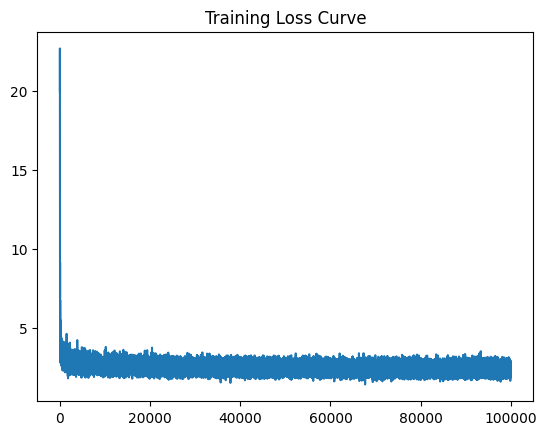

In [ ]:
plt.title("Training Loss Curve")
plt.plot(step_list, loss_step)

# trailing spikes/thrashing can be made smoother by increasing mini-batch size

In [ ]:
# Train

embed = C[xTr]
hidden = torch.tanh(embed.view(xTr.shape[0], -1) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, yTr)

print(loss.item())

2.3532321453094482


In [ ]:
# Evaluate

embed = C[xDev]
hidden = torch.tanh(embed.view(xDev.shape[0], -1) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, yDev)

print(loss.item())

2.3639705181121826


Roughly got to a lower training and evaluation loss compared to previous hidden_size. Both training and validation loss are still comparable, so we're STILL underfitting. Since this isn't improving any further, the bottleneck could in fact be the embedding dim size. Too much info squished into 2 dimensions??

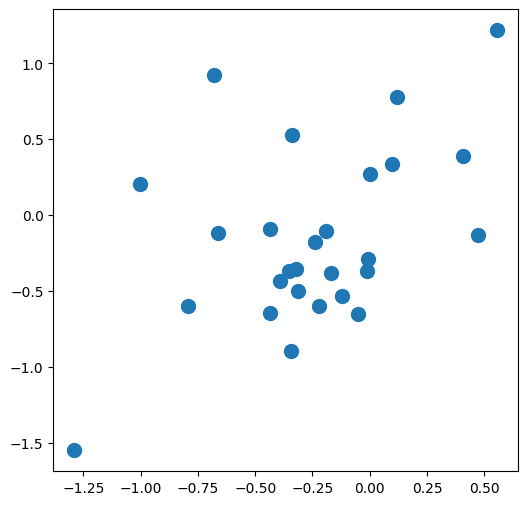

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(C[:,0].data, C[:, 1].data, s=100) # C is now learnt

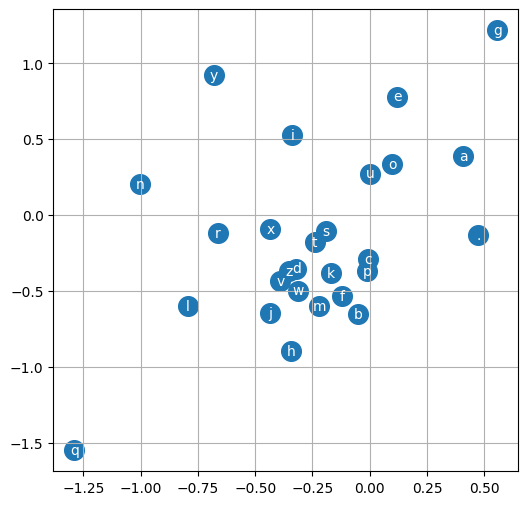

In [ ]:
# Name points
plt.figure(figsize=(6, 6))
plt.scatter(C[:,0].data, C[:, 1].data, s= 200) # C is now learnt

for i in range(C.shape[0]):
  plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")

plt.grid("minor")

# Experiment 2: Increasing Embedding size

In [ ]:
# initialize parameters
hidden_size = 200
embed_size = 10 # increased from 2
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size), generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, output_size), generator=g)
b2 = torch.randn(output_size, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [ ]:
# Train
step_list = []
loss_step = []
log_loss_step = []

for i in range(200000):
  # forward pass

  # randomly sample a minibatch of size 32 from the dataset of size xTr.shape[0]
  ind = torch.randint(0, xTr.shape[0], (32, )) # so stupid that it takes a tuple, but I do see the generalizability aspect

  embed = C[xTr[ind]]
  hidden = torch.tanh(embed.view(xTr[ind].shape[0], -1) @ W1 + b1)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward pass
  for p in parameters: #--> equivalent to zero grad
    p.grad = None

  loss.backward()


  # update weights
  lr = 10**-1
  # lr = 0.001

  # custom decay of learning rate
  lr = 0.1 if i < 100000 else 0.01

  for p in parameters:
    p.data += -lr * p.grad


  # track stats
  step_list.append(i)
  loss_step.append(loss.item()) ## hockey stick looking
  log_loss_step.append(loss.log10().item()) ## squashed hockey stick

print(loss.item())

2.137873411178589


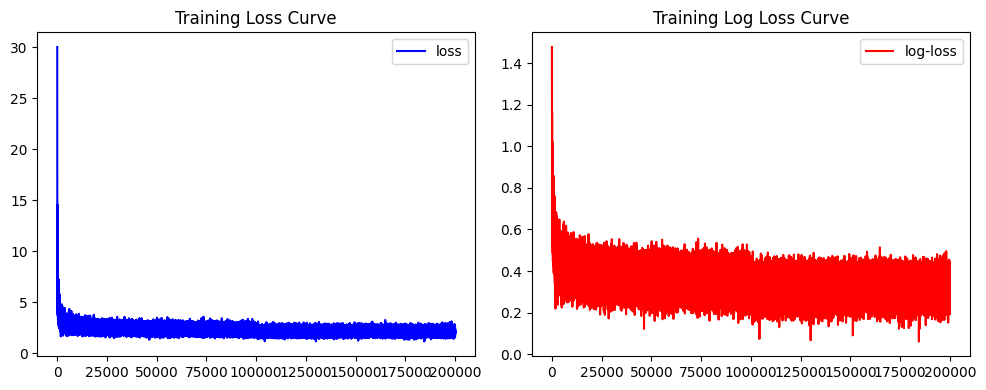

In [ ]:
# plt.title("Training Loss Curve")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Plot on the first subplot
axes[0].plot(step_list, loss_step, color='b', label='loss')
axes[0].set_title('Training Loss Curve')
axes[0].legend()

# Plot on the second subplot
axes[1].plot(step_list, log_loss_step, color='r', label='log-loss')
axes[1].set_title('Training Log Loss Curve')
axes[1].legend()

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# Train

embed = C[xTr]
hidden = torch.tanh(embed.view(xTr.shape[0], -1) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, yTr)

print(loss.item())

2.1230525970458984


In [ ]:
# Evaluate

embed = C[xDev]
hidden = torch.tanh(embed.view(xDev.shape[0], -1) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, yDev)

print(loss.item())

2.1675329208374023


Given that we are indeed getting a lower loss after increasing the embedding size, it is proved that the embedding size was in fact the bottleneck holding us back.

**TODO** *other hyperparameter fixes to try to get lower than 2.18 val-loss*

1.   Increase the context length to 4 from 3
2.   Tweak the batch size of training set
3.   Different learning rate decay schedule
4.   Tweak hidden size, tweak embed size
5.   Improvements suggested in the Bengio MLP paper - https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf



In [ ]:
# Test

embed = C[xTe]
hidden = torch.tanh(embed.view(xTe.shape[0], -1) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, yTe)

print(loss.item())

2.167353868484497


# Generating names i.e. INFERENCE

In [ ]:
context = [0]*block_size
torch.tensor([context]).shape

torch.Size([1, 3])

In [ ]:
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [ ]:
for _ in range(20):

  out = []
  context = [0]*block_size

  while True:
    embedding = C[torch.tensor([context])]
    hidden = torch.tanh(embedding.view(1, -1) @ W1 + b1)
    logits = hidden@W2 + b2
    probs = F.softmax(logits, dim=1)

    ix = torch.multinomial(probs, num_samples = 1, replacement= True, generator=g).item()
    context = context[1:] + [ix]
    if ix == 0:
      break
    out.append(ix)

  print(''.join(itos[j] for j in out))

ayelaisiya
uce
avaiganyya
giora
eswathed
asandi
gay
adort
rissa
ara
amayani
driellonetti
adson
kariai
geon
malane
avarthit
choze
pristia
malaylahna
